In [1]:
import numpy as np

from sklearn.datasets import make_blobs

# środki naszych klastrów

centroids = np.array([
    [ 0.8, 2.0],
    [-0.5, 2.0],
    [-2.0, 2.0],
    [-2.5, 2.5],
    [-2.5, 1.0]
])

# wprowadzenie szumu do naszych klastrów, aby rozrzucić próbki
blob_std = np.array([0.4, 0.3, 0.1, 0.1, 0.1])

# stworzenie zbioru danych
X, y = make_blobs(
    n_samples=3000,
    centers=centroids,
    cluster_std=blob_std,
    random_state=7
)

In [2]:
from sklearn.cluster import KMeans

clf = KMeans(n_clusters=5)

# możemy użyć metod fit(), predict()
clf.fit(X)
y_pred = clf.predict(X)

# albo metody fit)predict, która łączy dwie powyższe
y_pred = clf.fit_predict(X)

In [4]:
from sklearn.cluster import KMeans

clf = KMeans(n_clusters=5)

# możemy użyć metod fit(), predict()
clf.fit(X)
y_pred = clf.predict(X)

# albo metody fit)predict, która łączy dwie powyższe
y_pred = clf.fit_predict(X)

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def plot_decision_boundaries(clf, X, y=None):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)

    if y is not None:
        plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k')
    else:
        plt.scatter(X[:, 0], X[:, 1], edgecolor='k')

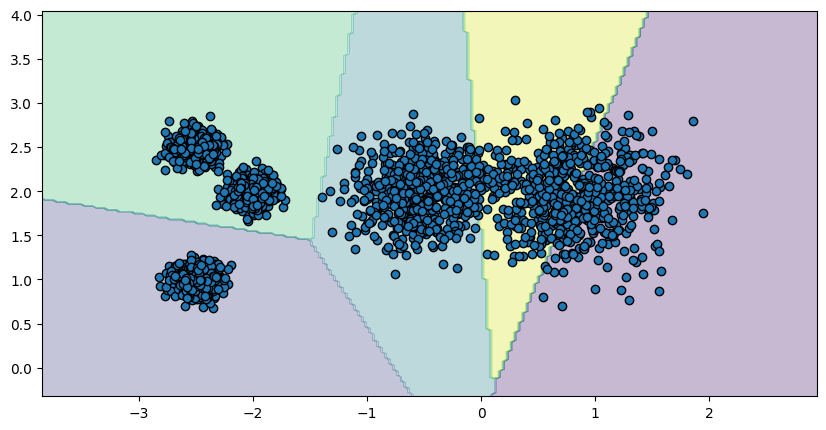

In [8]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plot_decision_boundaries(clf, X)
plt.show()

In [9]:
centroids = np.array([
    [ 0.8, 2.0],
    [-0.5, 2.0],
    [-2.0, 2.0],
    [-2.5, 2.5],
    [-2.5, 1.0]
])

blob_std = np.array([0.4, 0.3, 0.1, 0.1, 0.1])

# 3 miliony punktów!!!
X, y = make_blobs(
    n_samples=30000000,
    centers=centroids,
    cluster_std=blob_std,
    random_state=7
)

In [10]:
# tworzymy 19 algorytmów z k od 1 do 19
kmeans_per_k = [
    KMeans(n_clusters=k, random_state=2).fit(X)
    for k in range(2, 20) # zaczynamy od wartości n_clusters wynoszącej 2, gdyż nie ma sensu dzielenia zbioru dla 1 klastra
]

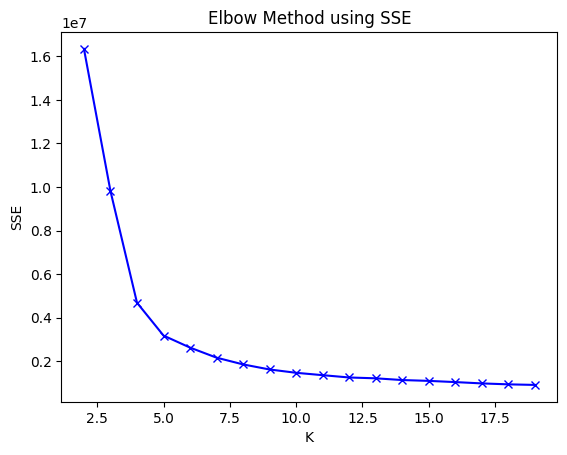

In [11]:
import matplotlib.pyplot as plt
inertias = [model.inertia_ for model in kmeans_per_k]
plt.plot(range(2, 20), inertias, 'bx-')
plt.xlabel('K')
plt.ylabel('SSE')
plt.title('Elbow Method using SSE')
plt.show()

In [12]:
from sklearn.metrics import silhouette_score

silhouette_scores = [
    silhouette_score(X, model.labels_)
    for model in kmeans_per_k
]

KeyboardInterrupt: 

In [ ]:
from matplotlib import pyplot as plt

plt.figure(figsize=(8, 3))
plt.plot(range(2, 10), silhouette_scores, "bo-")
plt.ylabel("Silhouette score", fontsize=14)
plt.grid()
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

X_digits, y_digits = load_digits(return_X_y=True)
X_train, X_test, y_train, y_test = \
    train_test_split(X_digits, y_digits, random_state=2)

log_reg = LogisticRegression(multi_class="ovr", max_iter=5000, random_state=2)
log_reg.fit(X_train, y_train)

print("Bez KMeans :", log_reg.score(X_test, y_test))

pipeline = Pipeline([
    ("kmeans", KMeans(
        n_clusters=40,
        random_state=2
    )),
    ("log_reg", LogisticRegression(
        multi_class="ovr",
        max_iter=5000,
        random_state=2
    )),
])
pipeline.fit(X_train, y_train)

print("Z KMeans :", pipeline.score(X_test, y_test))

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons

# tworzymy zbiór moon
X, y = make_moons(n_samples=1000, noise=0.08)

# tworzymy pierwszy klasyfikator DBSCAN z eps = 0.05
dbscan = DBSCAN(eps=0.05, min_samples=5)
dbscan.fit(X)

# drugi DBSCAN z eps = 0.2 (większy epsilon, większa przestrzeń wokół)
dbscan_2 = DBSCAN(eps=0.2, min_samples=5)
dbscan_2.fit(X)

In [ ]:
KMeans_clf = KMeans(n_clusters=2, max_iter=100000)
KMeans_clf.fit(X)

plot_decision_boundaries(KMeans_clf, X)

In [ ]:
from sklearn.datasets import make_blobs
import numpy as np

# tworzymy "bloby", czyli grupy danych
X1, y1 = make_blobs(n_samples=800, centers=((2, -2), (-2, 2)), random_state=2)
X1 = X1.dot(np.array([[0.374, 0.95], [0.732, 0.598]]))
X2, y2 = make_blobs(n_samples=200, centers=1, random_state=42)
X2 = X2 + [6, -8]

# przydatna metoda NumPy r_ - służy do składania dwóch tablic wg wybranej osi
X = np.r_[X1, X2]
y = np.r_[y1, y2]

In [ ]:
from sklearn.mixture import GaussianMixture

gm = GaussianMixture(n_components=3, n_init=10, random_state=42)
gm.fit(X)

plt.figure(figsize=(16, 8))

plot_gaussian_mixture(gm, X)
plt.show()